# Análisis de Tests A/B y Priorización de Hipótesis

Por Inti Alberto Romero González.

## Introducción

### Contexto del negocio
 Colaboramos como analistas con el departamento de marketing de una gran tienda online. El equipo ha recopilado una lista de hipótesis de mejora que, de implementarse, pueden incrementar los ingresos. El trabajo tiene dos etapas:

 1. **Priorizar** cuál hipótesis ejecutar primero usando frameworks de scoring
 2. **Evaluar** los resultados del test A/B para decidir si se adopta el cambio o se descarta 

| Dataset | Descripción | Variables clave |
|---|---|---|
| `hypotheses_us.csv` | Hipótesis de mejora con scores estimados | `Hypothesis`, `Reach`, `Impact`, `Confidence`, `Effort` |
| `orders_us.csv` | Registro de transacciones del test A/B | `transactionId`, `VisitorId`, `date`, `revenue`, `group` |
| `visits_us.csv` | Visitas diarias por grupo del test | `date`, `group`, `visits` |

### Preguntas que guían el análisis
1. **¿Cuál hipótesis tiene mayor potencial de impacto real?** — Comparar el ranking ICE vs. RICE para entender cómo cambia la prioridad al incorporar el alcance
2. **¿El Grupo B convierte más que el Grupo A?** — Determinar si la diferencia en tasa de conversión es estadísticamente significativa
3. **¿El Grupo B genera tickets más altos?** — Evaluar si la diferencia en tamaño promedio de pedido sobrevive la limpieza de outliers
4. **¿Es válido el test A/B?** — Detectar anomalías, usuarios en ambos grupos y sesgos que puedan invalidar los resultados
5. **¿Cuándo y cómo se debe detener el test?** — Decidir si los datos actuales son suficientes para una conclusión

### Objetivo final
Producir una **recomendación accionable**: qué hipótesis implementar primero y si el test A/B en curso debe adoptarse, extenderse o descartarse.

## Preparación de datos
Primero garantizamos que los tres datasets estén correctamente cargados, que los tipos de datos sean consistentes, y que el dataset de órdenes esté libre de ruido cruzado (usuarios asignados a ambos grupos simultáneamente)

In [3]:
# Importación de líbrerías
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import datetime as dt

# Configuración para mejorar la visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [4]:
# Definimos diccionario con los 3 datasets
datasets_urls = {
    'hypotheses_us.csv': 'https://code.s3.yandex.net/datasets/hypotheses_us.csv',
    'orders_us.csv': 'https://code.s3.yandex.net/datasets/orders_us.csv',
    'visits_us.csv': 'https://code.s3.yandex.net/datasets/visits_us.csv'
}

def descargar_datasets(urls_dict, carpeta_destino='data'):
    """
    Descarga múltiples datasets desde un diccionario de URLs 
    y lo guarda en la carpeta 'data', si no existe.
    """
    # Verificar si la carpeta de destino existe, si no, crearla
    if not os.path.exists(carpeta_destino):
        os.makedirs(carpeta_destino)
        print(f"📁 Carpeta '{carpeta_destino}' creada para almacenar los datasets.")

    # Variable para controlar si todas las descargas fueron exitosas
    todas_descargadas = True

    for filename, url in urls_dict.items():
        archivo = os.path.join(carpeta_destino, filename)
        print(f"\n--- 🔍 Procesando: {filename} ---")

        # Verifica si el archivo ya existe
        if os.path.exists(archivo):
            print(f"✅ El archivo {archivo} ya existe")
            continue  # Saltar a la siguiente iteración
        
        # Descargar el archivo
        print(f"📥 Descargando el dataset desde {url}...")
        try:
            response = requests.get(url)
            response.raise_for_status()  # Verifica que la descarga fue exitosa

            # Guarda el archivo descargado
            with open(archivo, 'wb') as f:
                f.write(response.content)

            # Verifica que se descargó correctamente        
            if os.path.exists(archivo):
                file_size = os.path.getsize(archivo) / (1024*1024)  # Tamaño en MB
                print(f"✅ Dataset descargado y guardado en {archivo} ({file_size:.2f} MB)")
    
        except requests.exceptions.RequestException as e:
            print(f"❌ ERROR al descargar el dataset: {e}")
            return False
        except Exception as e:
            print(f"❌ ERROR inesperado: {e}")
            return False
        
    return todas_descargadas
    
# Ejecutar la función de descarga
if descargar_datasets(datasets_urls):
        print("\n🚀 ¡Listo para comenzar el análisis!")

📁 Carpeta 'data' creada para almacenar los datasets.

--- 🔍 Procesando: hypotheses_us.csv ---
📥 Descargando el dataset desde https://code.s3.yandex.net/datasets/hypotheses_us.csv...
✅ Dataset descargado y guardado en data\hypotheses_us.csv (0.00 MB)

--- 🔍 Procesando: orders_us.csv ---
📥 Descargando el dataset desde https://code.s3.yandex.net/datasets/orders_us.csv...
✅ Dataset descargado y guardado en data\orders_us.csv (0.05 MB)

--- 🔍 Procesando: visits_us.csv ---
📥 Descargando el dataset desde https://code.s3.yandex.net/datasets/visits_us.csv...
✅ Dataset descargado y guardado en data\visits_us.csv (0.00 MB)

🚀 ¡Listo para comenzar el análisis!


In [5]:
# Crear carpeta para almacenar las visualizaciones
images = 'images'
if not os.path.exists(images):
    os.makedirs(images)
    print(f"\n📁 Carpeta '{images}' creada para almacenar las visualizaciones.")
else:
    print(f"\n📁 La carpeta '{images}' ya existe.")


📁 Carpeta 'images' creada para almacenar las visualizaciones.


In [8]:
# Carga de dataframes
try:
    hypotheses = pd.read_csv('data/hypotheses_us.csv', sep=';')
    orders = pd.read_csv('data/orders_us.csv')
    visits = pd.read_csv('data/visits_us.csv')
    print("Datos cargados exitosamente.")
    # Visualizar las primeras filas de cada DataFrame para verificar su contenido
    print("📊 Dataset 'hypotheses':")
    print(hypotheses.head())
    print("\n📊 Dataset 'orders_us':")
    print(orders.head())
    print("\n📊 Dataset 'visits_us':")
    print(visits.head())
except:
    print("Error al cargar los datos. Verifica la ruta del archivo.")

Datos cargados exitosamente.
📊 Dataset 'hypotheses':
                                                                                                               Hypothesis  \
0                                             Add two new channels for attracting traffic. This will bring 30% more users   
1                                                       Launch your own delivery service. This will shorten delivery time   
2          Add product recommendation blocks to the store's site. This will increase conversion and average purchase size   
3  Change the category structure. This will increase conversion since users will find the products they want more quickly   
4                                        Change the background color on the main page. This will increase user engagement   

   Reach  Impact  Confidence  Effort  
0      3      10           8       6  
1      2       5           4      10  
2      8       3           7       3  
3      8       3           3       8  
4

### Procesamiento y limpieza de datos
**Pasos de limpieza:**
1. **Revisión de estructura**: tipos de datos, nulos y consistencia general
2. **Conversión de fechas**: las columnas `date` deben ser `datetime64` para calcular acumulados y ventanas temporales
3. **Detección de usuarios duplicados entre grupos**: un usuario que aparece en A y en B contamina los resultados del test — debe ser excluido

In [11]:
# Revisión rápida
print("--- Info Hypotheses ---")
hypotheses.info()
print("\n--- Info Orders ---")
orders.info()
print("\n--- Info Visits ---")
visits.info()

# Conversión de fechas a tipo datetime
orders['date'] = pd.to_datetime(orders['date'])
visits['date'] = pd.to_datetime(visits['date'])

#Confirmar que las conversiones se realizaron correctamente
for df_name, df in zip(['orders', 'visits'], [orders, visits]):
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        print(f"\nFechas convertidas a datetime en el dataset '{df_name}'.")
    else:
        print(f"\nNo se encontró la columna 'date' en el dataset '{df_name}'.")

--- Info Hypotheses ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Hypothesis  9 non-null      object        
 1   Reach       9 non-null      int64         
 2   Impact      9 non-null      int64         
 3   Confidence  9 non-null      int64         
 4   Effort      9 non-null      int64         
 5   date        9 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 564.0+ bytes

--- Info Orders ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   

In [14]:
# Mostrar tabla hypotheses
print("--- Tabla Hypotheses ---")
hypotheses

--- Tabla Hypotheses ---


,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. This will bring 30% more users,3,10,8,6
1,Launch your own delivery service. This will shorten delivery time,2,5,4,10
2,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,8,3,7,3
3,Change the category structure. This will increase conversion since users will find the products they want more quickly,8,3,3,8
4,Change the background color on the main page. This will increase user engagement,3,1,1,1
5,Add a customer review page. This will increase the number of orders,3,2,2,3
6,Show banners with current offers and sales on the main page. This will boost conversion,5,3,8,3
7,Add a subscription form to all the main pages. This will help you compile a mailing list,10,7,8,5
8,Launch a promotion that gives users discounts on their birthdays,1,9,9,5


In [16]:
#Mostrar tabla orders
print("--- Tabla Orders ---")
orders

--- Tabla Orders ---


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B
...,...,...,...,...,...
1192,2662137336,3733762160,2019-08-14,100.8,B
1193,2203539145,370388673,2019-08-14,50.1,A
1194,1807773912,573423106,2019-08-14,165.3,A
1195,1947021204,1614305549,2019-08-14,5.5,A


In [17]:
#Mostrar tabla Visits
print("--- Tabla Visits ---")
visits

--- Tabla Visits ---


,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756
...,...,...,...
57,2019-08-27,B,720
58,2019-08-28,B,654
59,2019-08-29,B,531
60,2019-08-30,B,490


In [14]:
# Identificar usuarios que están en el grupo A y en el grupo B
users_a = orders[orders['group'] == 'A']['visitorId'].unique()
users_b = orders[orders['group'] == 'B']['visitorId'].unique()

# Encontrar la intersección (usuarios en ambos grupos)
users_both_groups = np.intersect1d(users_a, users_b)

print(f"Número de usuarios en el grupo A: {len(users_a)}")
print(f"Número de usuarios en el grupo B: {len(users_b)}")
print(f"Usuarios que aparecen en ambos grupos: {len(users_both_groups)}")

# Filtrar el dataset orders para dejar solo usuarios que están en un solo grupo
orders_clean = orders[~orders['visitorId'].isin(users_both_groups)]

#Guardar el dataset 'orders_clean' para futuras referencias
orders_clean.to_csv('data/orders_clean.csv', index=False)

print(f"Tamaño original de orders: {len(orders)}")
print(f"Tamaño de orders después de limpiar: {len(orders_clean)}")

Número de usuarios en el grupo A: 503
Número de usuarios en el grupo B: 586
Usuarios que aparecen en ambos grupos: 58
Tamaño original de orders: 1197
Tamaño de orders después de limpiar: 1016


**Resultado de la limpieza de grupos:**

Se identificaron y eliminaron **58 usuarios** que aparecían simultáneamente en el Grupo A y el Grupo B. Su presencia contaminaría las comparaciones: al haber sido expuestos a ambas condiciones, no podemos atribuir su comportamiento a ninguna de las dos.

> 💡 **¿Por qué ocurre esto?** En tests A/B mal instrumentados, un mismo usuario puede ser asignado a grupos distintos si visita desde dispositivos diferentes o si la cookie se resetea. Es una de las anomalías más comunes y dañinas en experimentación.

In [15]:
users_a = orders_clean[orders_clean['group'] == 'A']['visitorId'].unique()
users_b = orders_clean[orders_clean['group'] == 'B']['visitorId'].unique()
users_both_groups = np.intersect1d(users_a, users_b)
print(f"Número de usuarios en el grupo A: {len(users_a)}")
print(f"Número de usuarios en el grupo B: {len(users_b)}")
print(f"Usuarios que aparecen en ambos grupos: {len(users_both_groups)}")

Número de usuarios en el grupo A: 445
Número de usuarios en el grupo B: 528
Usuarios que aparecen en ambos grupos: 0


## Parte 1 — Priorización de Hipótesis

Antes de lanzar un test A/B, hay que decidir **qué probar**. Con recursos limitados y múltiples hipótesis compitiendo, se necesita un criterio objetivo para ordenarlas.

Aplicaremos dos frameworks de priorización ampliamente usados en product management y growth:

### Frameworks ICE y RICE

Ambos frameworks puntúan cada hipótesis según variables estimadas por el equipo. La diferencia clave está en si se considera el **alcance** de la iniciativa.

| Variable | Significado | Rango típico |
|---|---|---|
| **Reach** | ¿A cuántos usuarios impacta por período? | Nº de usuarios |
| **Impact** | ¿Cuánto mejora la métrica objetivo si funciona? | 0.5 (mínimo) → 3 (máximo) |
| **Confidence** | ¿Qué tan seguros estamos de que funcionará? | 0–100% |
| **Effort** | ¿Cuánto cuesta implementarlo? | 1 (mínimo) → 10 (máximo) |

**Fórmulas:**

$$ICE = \frac{Impact \times Confidence}{Effort}$$

$$RICE = \frac{Reach \times Impact \times Confidence}{Effort}$$

**La diferencia crítica:** ICE ignora a cuántos usuarios llega la iniciativa. RICE lo penaliza o premia explícitamente. Una mejora que aplica al 0.1% de los usuarios tiene un score ICE igual que una que aplica al 100% — RICE los distingue.

--- Hipótesis ordenadas por ICE (Top 5) ---


,Hypothesis,ICE
8,Launch a promotion that gives users discounts on their birthdays,16.200000
0,Add two new channels for attracting traffic. This will bring 30% more users,13.333333
7,Add a subscription form to all the main pages. This will help you compile a mailing list,11.200000
6,Show banners with current offers and sales on the main page. This will boost conversion,8.000000
2,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,7.000000



--- Hipótesis ordenadas por RICE (Top 5) ---


,Hypothesis,RICE
7,Add a subscription form to all the main pages. This will help you compile a mailing list,112.0
2,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,56.0
0,Add two new channels for attracting traffic. This will bring 30% more users,40.0
6,Show banners with current offers and sales on the main page. This will boost conversion,40.0
8,Launch a promotion that gives users discounts on their birthdays,16.2


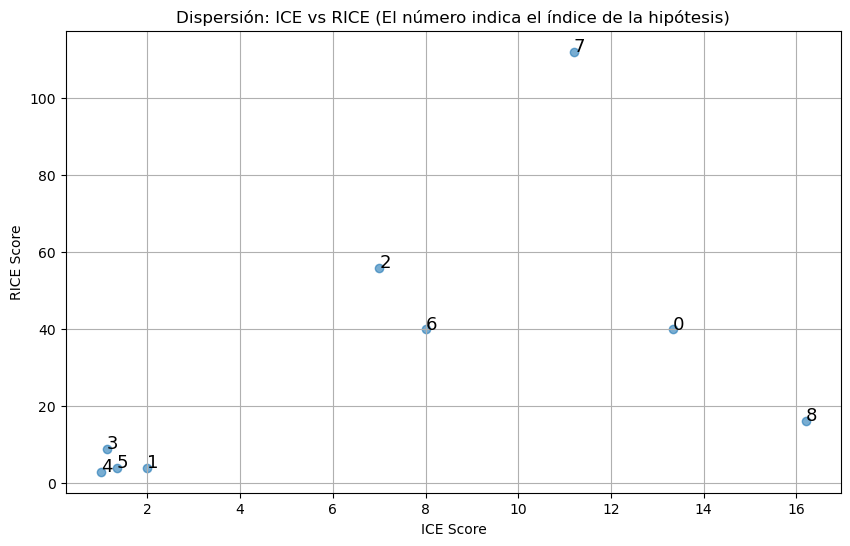

In [16]:
# Calcular ICE
hypotheses['ICE'] = (hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']

# Calcular RICE
hypotheses['RICE'] = (hypotheses['Reach'] * hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']

# Visualización de los cambios de prioridad
# Vamos a mostrar las hipótesis ordenadas por RICE, pero incluyendo la columna ICE para comparar
print("--- Hipótesis ordenadas por ICE (Top 5) ---")
display(hypotheses[['Hypothesis', 'ICE']].sort_values(by='ICE', ascending=False).head(5))

print("\n--- Hipótesis ordenadas por RICE (Top 5) ---")
display(hypotheses[['Hypothesis', 'RICE']].sort_values(by='RICE', ascending=False).head(5))

# Gráfico para visualizar mejor el cambio (Scatter plot: RICE vs ICE)
plt.figure(figsize=(10, 6))
for i, txt in enumerate(hypotheses.index):
    plt.annotate(txt, (hypotheses['ICE'][i], hypotheses['RICE'][i]), fontsize=13)

plt.scatter(hypotheses['ICE'], hypotheses['RICE'], alpha=0.6)
plt.xlabel('ICE Score')
plt.ylabel('RICE Score')
plt.title('Dispersión: ICE vs RICE (El número indica el índice de la hipótesis)')
plt.grid(True)
plt.show()

### Conclusiones Parte 1: ICE vs RICE

**Ganador ICE — Hipótesis 8 (Promoción de cumpleaños):**
Obtiene el primer lugar por su bajo esfuerzo y buen impacto estimado. En ICE, esto es suficiente.

**Ganador RICE — Hipótesis 7 (Formulario de suscripción):**
Al incorporar el factor `Reach`, la hipótesis 7 toma el primer lugar de forma indiscutible.

**El cambio de posición revela la trampa del ICE:**
La promoción de cumpleaños (H8) solo impacta a quienes cumplen años *ese día* — una fracción mínima del tráfico. Un formulario de suscripción en todas las páginas principales (H7) alcanza prácticamente al **100% de los visitantes**. Con el mismo esfuerzo, el potencial de impacto es incomparablemente mayor.

| Framework | Top 1 | Razonamiento |
|---|---|---|
| ICE | H8 — Cumpleaños | Bajo esfuerzo + buen impacto individual |
| RICE | H7 — Suscripción | Alto alcance multiplica el impacto real |

**Decisión:** Priorizamos la **Hipótesis 7** y aquellas con alto `Reach` (alcance). El alcance no es un detalle — es el multiplicador que separa iniciativas de alto impacto real de iniciativas de alto impacto teórico.

## Parte 2 — Análisis del Test A/B

Con la hipótesis priorizada e implementada en el **Grupo B**, ahora evaluamos los resultados del experimento.

El análisis sigue cuatro pasos:
1. **Métricas acumuladas:** visualizar ingresos, ticket promedio y conversión en el tiempo para detectar estabilidad y anomalías
2. **Detección de outliers:** identificar usuarios y pedidos atípicos que distorsionen los resultados
3. **Significancia estadística (datos en bruto):** prueba Mann-Whitney antes del filtrado
4. **Significancia estadística (datos filtrados):** misma prueba después de eliminar anomalías — los resultados deben ser consistentes para ser confiables

### ¿Por qué analizar métricas acumuladas?

Las métricas acumuladas día a día (en lugar de diarias) son estándar en análisis de A/B testing porque:
- **Suavizan el ruido** de los días individuales (un día con muchas ventas puede ser atípico)
- **Revelan tendencias** de largo plazo que las métricas diarias ocultan
- **Muestran estabilidad**: si las líneas se separan y se mantienen separadas, la señal es robusta; si siguen fluctuando, el test necesita más tiempo

Analizaremos tres métricas: ingreso acumulado, tamaño de pedido promedio acumulado, y tasa de conversión acumulada.

### Preparación de Datos Acumulados
Crearemos un dataframe `cumulativeData` que contenga, para cada día y grupo:
* Total de pedidos acumulados.
* Total de ingresos acumulados.
* Total de visitas acumuladas.

In [17]:
# Crear una matriz con todas las combinaciones únicas de fecha y grupo
datesGroups = orders_clean[['date', 'group']].drop_duplicates()

# Obtener los datos acumulados de los pedidos
ordersAggregated = datesGroups.apply(
    lambda x: orders_clean[
        np.logical_and(
            orders_clean['date'] <= x['date'],
            orders_clean['group'] == x['group']
        )
    ].agg({
        'date': 'max',
        'group': 'max',
        'transactionId': 'nunique',
        'visitorId': 'nunique',
        'revenue': 'sum'
    }), axis=1
).sort_values(by=['date', 'group'])

# Obtener los datos acumulados de las visitas
visitsAggregated = datesGroups.apply(
    lambda x: visits[
        np.logical_and(
            visits['date'] <= x['date'],
            visits['group'] == x['group']
        )
    ].agg({
        'date': 'max',
        'group': 'max',
        'visits': 'sum'
    }), axis=1
).sort_values(by=['date', 'group'])

# Fusionar ambas tablas
cumulativeData = ordersAggregated.merge(visitsAggregated, on=['date', 'group'])
cumulativeData.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visits']

#Guardar el dataset acumulado para futuras referencias
cumulativeData.to_csv('data/cumulative_data.csv', index=False)

print(cumulativeData.head())

        date group  orders  buyers  revenue  visits
0 2019-08-01     A      23      19   2266.6     719
1 2019-08-01     B      17      17    967.2     713
2 2019-08-02     A      42      36   3734.9    1338
3 2019-08-02     B      40      39   3535.3    1294
4 2019-08-03     A      66      60   5550.1    1845


### Ingreso acumulado y Tamaño de Pedido Promedio

**¿Qué buscamos?**
- En el **ingreso acumulado**: que un grupo genere consistentemente más — sin saltos abruptos que sugieran outliers
- En el **ticket promedio acumulado**: que la diferencia entre grupos sea estable y gradual. Un pico repentino en un día específico es señal de alerta.

A continuación, analizaremos:
1.  **Ingreso acumulado:** ¿Qué grupo está generando más dinero en total?
2.  **Tamaño de pedido promedio acumulado:** ¿Se gasta más en promedio por compra en algún grupo?

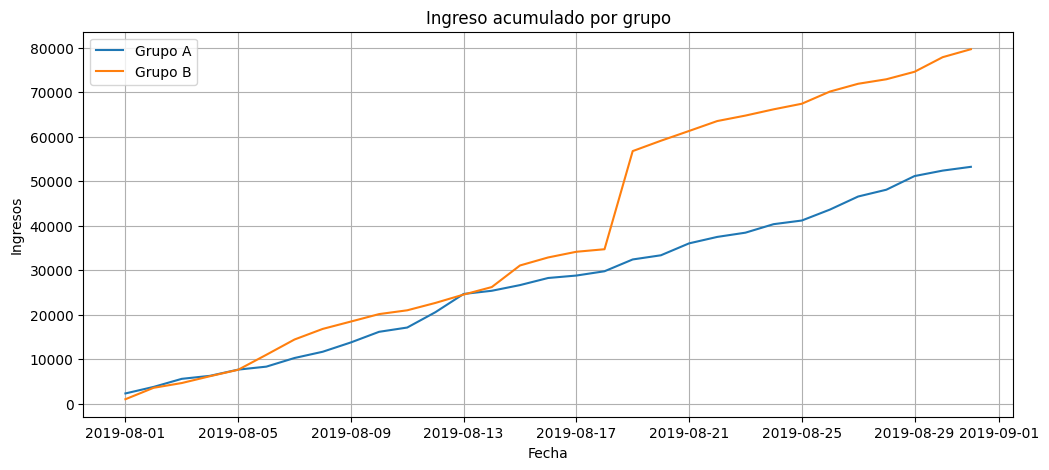

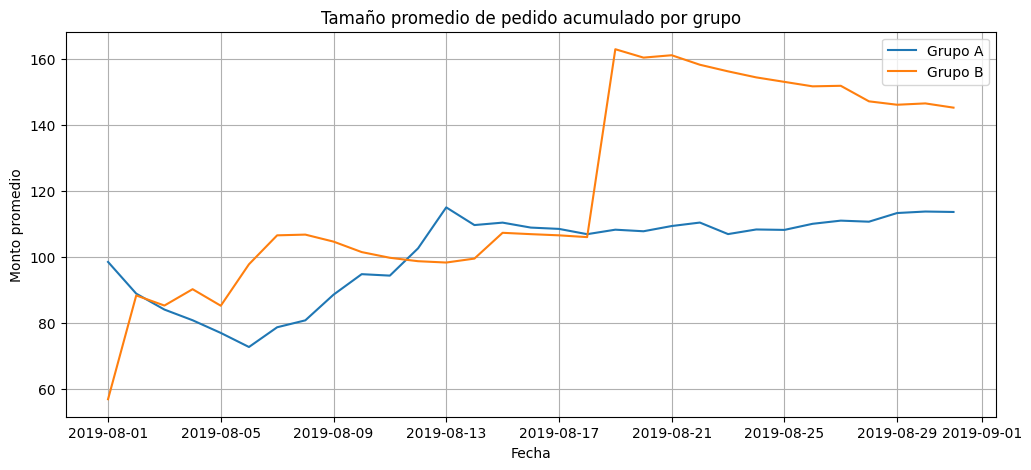

In [22]:
# Dataframes separados por grupo
cumulativeRevenueA = cumulativeData[cumulativeData['group']=='A'][['date','revenue', 'orders']]
cumulativeRevenueB = cumulativeData[cumulativeData['group']=='B'][['date','revenue', 'orders']]

# --- Gráfico 1: Ingreso acumulado ---
plt.figure(figsize=(12, 5))
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue'], label='Grupo A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue'], label='Grupo B')
plt.title('Ingreso acumulado por grupo')
plt.xlabel('Fecha')
plt.ylabel('Ingresos')
plt.legend()
plt.grid(True)
plt.show()

# --- Gráfico 2: Tamaño de pedido promedio acumulado ---
# El tamaño promedio es (Revenue / Orders)
plt.figure(figsize=(12, 5))
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue']/cumulativeRevenueA['orders'], label='Grupo A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue']/cumulativeRevenueB['orders'], label='Grupo B')
plt.title('Tamaño promedio de pedido acumulado por grupo')
plt.xlabel('Fecha')
plt.ylabel('Monto promedio')
plt.legend()
plt.grid(True)
plt.show()

#### Interpretación: Ingresos y Tamaño de Pedido

**Ingreso acumulado:**

| Observación | Interpretación |
|---|---|
| Crecimiento constante en ambos grupos en la primera quincena | El test corre en condiciones normales |
| Salto repentino en Grupo B alrededor del 18–19 de agosto | **Señal de alerta**: no es demanda orgánica, sino outliers de alto valor |
| Grupo B lidera al final del período | Liderazgo inflado artificialmente por esos pedidos atípicos |

**Ticket promedio acumulado:**

El pico masivo en Grupo B (superando 160 vs ~120 de A) ocurre el mismo día que el salto de ingresos. Después, la métrica desciende progresivamente — señal clásica de que el promedio está siendo "jalado" por unos pocos valores extremos.

> ⚠️ **Conclusión provisional:** No podemos confiar en las diferencias de ingreso y ticket promedio hasta filtrar los outliers. La conversión será la métrica más honesta.

### Diferencia relativa en ticket promedio acumulado (B vs. A)

Este gráfico normaliza la comparación: muestra qué tan por encima o por debajo del Grupo A se encuentra el Grupo B en términos de ticket promedio.

- **Línea por encima de 0** → Grupo B tiene ticket mayor
- **Línea en 0** → Grupos equivalentes
- **Saltos bruscos** → Presencia de outliers que distorsionan la comparación

En este gráfico compararemos el rendimiento relativo del Grupo B respecto al A.
* Si la línea está por encima de 0, el Grupo B tiene un ticket promedio mayor.
* Los picos repentinos confirman la presencia de pedidos anómalos.

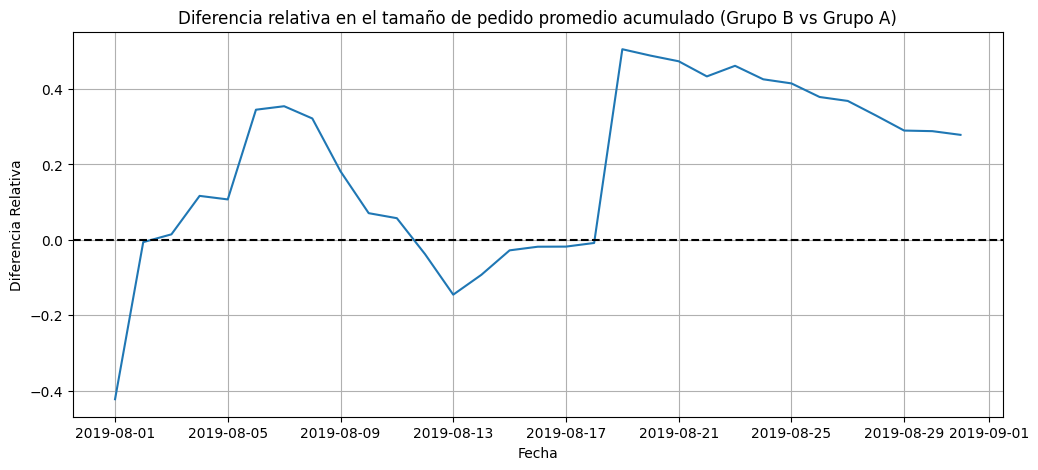

In [23]:
# Fusionar los datos acumulados de A y B
mergedCumulativeRevenue = cumulativeRevenueA.merge(
    cumulativeRevenueB,
    left_on='date',
    right_on='date',
    how='left',
    suffixes=['A', 'B']
)

plt.figure(figsize=(12, 5))

# Calcular la diferencia relativa: (PromedioB / PromedioA) - 1
plt.plot(
    mergedCumulativeRevenue['date'],
    (mergedCumulativeRevenue['revenueB']/mergedCumulativeRevenue['ordersB']) /
    (mergedCumulativeRevenue['revenueA']/mergedCumulativeRevenue['ordersA']) - 1
)

# Agregar línea base en 0 (donde A = B)
plt.axhline(y=0, color='black', linestyle='--')

plt.title('Diferencia relativa en el tamaño de pedido promedio acumulado (Grupo B vs Grupo A)')
plt.xlabel('Fecha')
plt.ylabel('Diferencia Relativa')
plt.grid(True)
plt.show()

#### Conclusiones y Conjeturas: Diferencia Relativa

**Diferencia relativa en tamaño de pedido promedio (B vs A):**
* **Observación:** La gráfica sufre cambios bruscos y repentinos. Vemos picos altos (donde B supera a A por mucho) seguidos de caídas. Destaca el pico masivo alrededor del 18 de agosto.
* **Conclusión:** La métrica del tamaño de pedido promedio no es estable.
* **Conjetura:** Esta volatilidad confirma nuevamente la presencia de valores atípicos (outliers) significativos. Los momentos donde la línea salta bruscamente corresponden probablemente a días donde se realizaron compras inusualmente grandes en el grupo B. No podemos confiar plenamente en esta métrica hasta filtrar esos datos.

#### Interpretación: Diferencia Relativa en Ticket Promedio

La gráfica es **inestable**: sube y baja abruptamente en lugar de converger gradualmente hacia un valor estable.

**Lectura:**
- Los picos bruscos (especialmente el del 18 de agosto) confirman la presencia de pedidos anómalamente grandes en Grupo B en días específicos
- La métrica no está midiendo el comportamiento real del usuario promedio — está siendo manipulada por casos extremos
- Una métrica que no se estabiliza con el tiempo **no es concluyente**, independientemente de su valor puntual

> 💡 **Regla práctica en A/B testing:** Si la diferencia relativa acumulada sigue oscilando violentamente hacia el final del período, el test está dominado por ruido. La señal legítima debe converger.

### Tasa de Conversión Acumulada

La **tasa de conversión** = pedidos / visitas. Es la métrica más limpia del test porque:
- No está afectada por el *tamaño* de los pedidos — solo por si el usuario compró o no
- Refleja directamente si el cambio en Grupo B hace que más usuarios decidan comprar

**Expectativa:** Fluctuaciones altas al inicio (pocos datos), convergencia y separación estable hacia el final.

La tasa de conversión es la relación entre pedidos y visitas. Analizaremos si un grupo convierte visitas en compras de manera más eficiente que el otro.
Espera ver fluctuaciones al principio, pero las líneas deberían separarse y estabilizarse hacia el final del mes.

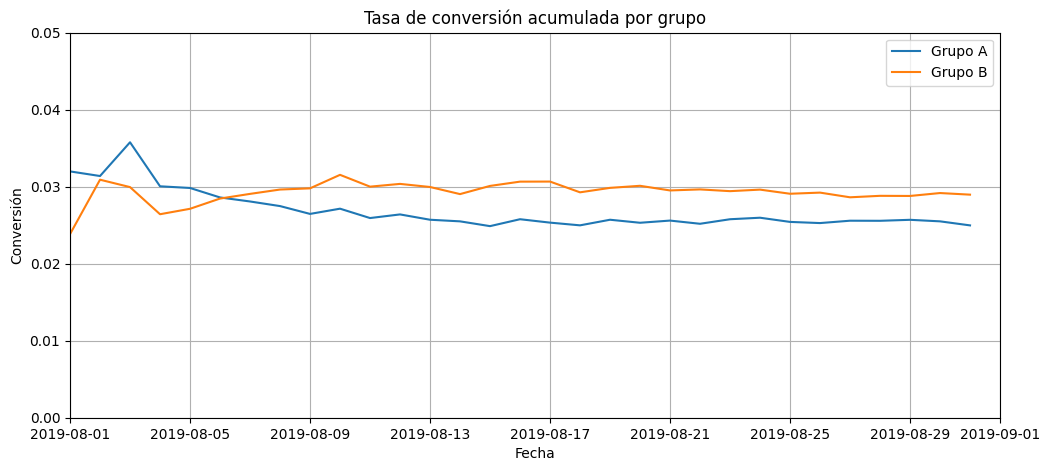

In [24]:
# Calcular conversión acumulada
cumulativeData['conversion'] = cumulativeData['orders'] / cumulativeData['visits']

# Separar datos por grupo
cumulativeDataA = cumulativeData[cumulativeData['group']=='A']
cumulativeDataB = cumulativeData[cumulativeData['group']=='B']

# Gráfico
plt.figure(figsize=(12, 5))
plt.plot(cumulativeDataA['date'], cumulativeDataA['conversion'], label='Grupo A')
plt.plot(cumulativeDataB['date'], cumulativeDataB['conversion'], label='Grupo B')
plt.title('Tasa de conversión acumulada por grupo')
plt.xlabel('Fecha')
plt.ylabel('Conversión')
plt.legend()
plt.grid(True)

# Definir escala del eje Y para ver mejor los detalles (ajusta si es necesario)
plt.axis([dt.datetime(2019, 8, 1), dt.datetime(2019, 9, 1), 0, 0.05])
plt.show()

#### Interpretación: Tasa de Conversión

| Período | Comportamiento |
|---|---|
| Primera semana | Alta volatilidad en ambos grupos — normal con pocos datos acumulados |
| Semana 2 en adelante | Las líneas se separan claramente y **se mantienen separadas** |
| Final del período | Grupo B consistentemente por encima de Grupo A |

**Conclusión:** El Grupo B tiene una mayor tasa de conversión que el Grupo A, y esta diferencia **no está contaminada por outliers** (la conversión solo depende de si el usuario compró, no de cuánto).

**Diferencia estimada visual:** ~16-18% de mejora en conversión para Grupo B.

> La estabilidad de esta métrica contrasta directamente con la volatilidad del ticket promedio. Esto ya anticipa dónde estará la señal significativa en las pruebas estadísticas.

### Detección de Anomalías (Outliers)

Antes de correr las pruebas estadísticas definitivas, debemos identificar y filtrar dos tipos de anomalías:

| Tipo | ¿Qué es? | Riesgo si no se filtra |
|---|---|---|
| **Usuarios con muchos pedidos** | Un usuario que compra 10 veces vs. el promedio de 1 | Infla la tasa de conversión de su grupo artificialmente |
| **Pedidos de precio extremo** | Una sola compra de $5,000 vs. el promedio de $100 | Infla el ticket promedio de su grupo artificialmente |

Usaremos los **percentiles 95 y 99** como referencia para definir el umbral de corte. Esta decisión es semi-subjetiva — lo importante es documentarla y aplicarla consistentemente a ambos grupos.

Para limpiar los datos y mejorar la precisión de nuestras pruebas estadísticas, primero debemos identificar los valores atípicos (outliers).

Analizaremos:
1.  **Pedidos por usuario:** Visualización y cálculo de los percentiles 95 y 99.
2.  **Precios de pedidos:** Visualización y cálculo de los percentiles 95 y 99.

El objetivo es definir un **umbral** (límite) para filtrar los datos en el siguiente paso.

--- Estadísticas de pedidos por usuario ---
      visitorId  orders
478  2108163459       3
55    249864742       3
138   611059232       3
632  2742574263       3
687  2988190573       3
890  3908431265       3
908  3967698036       3
118   522292794       2
94    406208401       2
323  1404560065       2


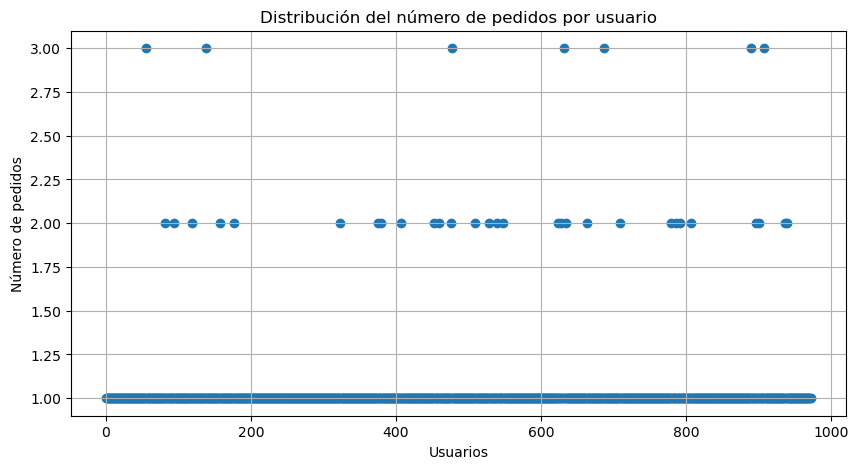

Percentil 95 de pedidos por usuario: 1.0
Percentil 99 de pedidos por usuario: 2.0


In [19]:

# --- 1. Pedidos por usuario ---

# Agrupamos por usuario y contamos sus pedidos únicos
ordersByUsers = (
    orders_clean.drop(['group', 'revenue', 'date'], axis=1)
    .groupby('visitorId', as_index=False)
    .agg({'transactionId': 'nunique'})
)
ordersByUsers.columns = ['visitorId', 'orders']

print("--- Estadísticas de pedidos por usuario ---")
print(ordersByUsers.sort_values(by='orders', ascending=False).head(10))

# Gráfico de dispersión
x_values = pd.Series(range(0, len(ordersByUsers)))

plt.figure(figsize=(10, 5))
plt.scatter(x_values, ordersByUsers['orders'])
plt.title('Distribución del número de pedidos por usuario')
plt.ylabel('Número de pedidos')
plt.xlabel('Usuarios')
plt.grid(True)
plt.show()

# Cálculo de percentiles
percentiles_orders = np.percentile(ordersByUsers['orders'], [95, 99])
print(f"Percentil 95 de pedidos por usuario: {percentiles_orders[0]}")
print(f"Percentil 99 de pedidos por usuario: {percentiles_orders[1]}")


--- Estadísticas de precios de pedidos (Top 10 más caros) ---
      transactionId   visitorId       date  revenue group
425       590470918  1920142716 2019-08-19  19920.4     B
1196     3936777065  2108080724 2019-08-15   3120.1     B
1136      666610489  1307669133 2019-08-13   1425.8     A
744      3668308183   888512513 2019-08-27   1335.6     B
743      3603576309  4133034833 2019-08-09   1050.0     A
1103     1348774318  1164614297 2019-08-12   1025.8     A
1099      316924019   148427295 2019-08-12   1015.9     A
949      1347999392   887908475 2019-08-21    930.0     A
940      2420050534  4003628586 2019-08-08    905.8     B
131      3163614039  2254586615 2019-08-22    830.3     A


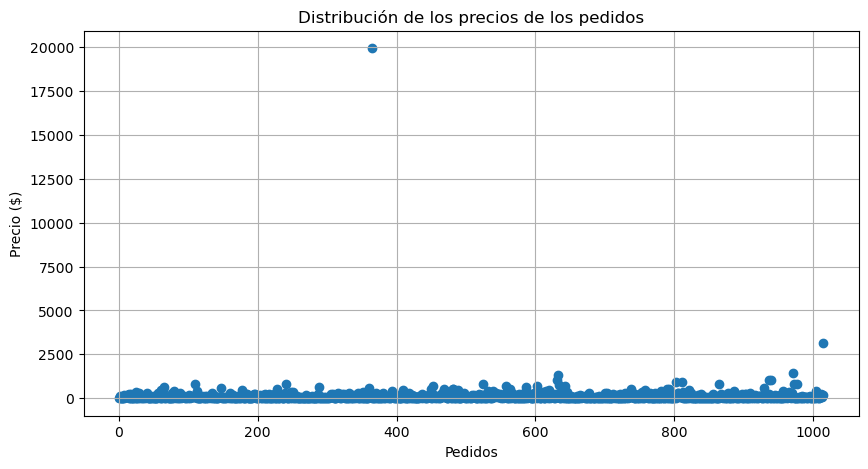

Percentil 95 de precio de pedido: 414.275
Percentil 99 de precio de pedido: 830.3


In [20]:
# --- 2. Precios de los pedidos ---

print("\n--- Estadísticas de precios de pedidos (Top 10 más caros) ---")
print(orders_clean.sort_values(by='revenue', ascending=False).head(10))

# Gráfico de dispersión
x_values = pd.Series(range(0, len(orders_clean)))

plt.figure(figsize=(10, 5))
plt.scatter(x_values, orders_clean['revenue'])
plt.title('Distribución de los precios de los pedidos')
plt.ylabel('Precio ($)')
plt.xlabel('Pedidos')
plt.grid(True)
plt.show()

# Cálculo de percentiles
percentiles_prices = np.percentile(orders_clean['revenue'], [95, 99])
print(f"Percentil 95 de precio de pedido: {percentiles_prices[0]}")
print(f"Percentil 99 de precio de pedido: {percentiles_prices[1]}")

#### Interpretación: Umbrales de Anomalías

**Pedidos por usuario:**

| Percentil | Valor | Decisión |
|---|---|---|
| 95 | 1 pedido | El 95% de usuarios compra una sola vez |
| 99 | 2 pedidos | Solo el 1% compra más de 2 veces |
| **Umbral elegido** | **> 2 pedidos** | Usuarios con 3+ pedidos son anómalos |

**Precios de pedidos:**

| Percentil | Valor | Decisión |
|---|---|---|
| 95 | $414.27 | El 95% de pedidos está por debajo de este valor |
| 99 | $830.30 | Solo el 1% supera los $830 |
| **Umbral elegido** | **> $415** | Pedidos por encima del p95 se consideran atípicos |

---

> 💡 **¿Por qué p95 para precios y p99 para pedidos?** Los precios extremos tienen mayor capacidad de distorsionar el promedio (un pedido de $5,000 equivale a 50 pedidos de $100). Los pedidos múltiples son más raros aún y su efecto sobre la conversión es más contenido. El criterio debe ser conservador: si filtramos demasiado, perdemos casos reales.

### Análisis de Significancia Estadística

Utilizamos la prueba de **Mann-Whitney U** — no la prueba t de Student — porque:
- Los datos de pedidos y revenue **no siguen una distribución normal**: están fuertemente sesgados a la derecha (muchos ceros, pocos valores altos)
- Mann-Whitney compara las distribuciones completas de ambos grupos sin asumir normalidad
- Es el estándar en análisis de A/B testing en e-commerce con estas características

**Nivel de significancia:** α = 0.05 (si el p-value es menor, rechazamos H₀)

Corremos el test en **dos rondas**:
1. Con datos en bruto — para ver el estado inicial
2. Con datos filtrados — para ver la señal real sin ruido de outliers

#### Hipótesis estadísticas
**Hipótesis para la Conversión:**
* $H_0$: No hay diferencia en la tasa de conversión entre el grupo A y B.
* $H_1$: Hay una diferencia significativa en la tasa de conversión entre los grupos.

**Hipótesis para el Pedido Promedio:**
* $H_0$: No hay diferencia en el tamaño promedio de pedido entre el grupo A y B.
* $H_1$: Hay una diferencia significativa en el tamaño promedio de pedido.

**Nivel de significancia:** $\alpha$ = 0.05

In [21]:
# --- Preparación de datos para Mann-Whitney ---

# Vamos a crear dos series para cada grupo (A y B)
# Estas series contendrán el número de pedidos por cada usuario.
# Si un usuario no compró, tendrá un 0.

# 1. Usuarios que compraron
ordersByUsersA = orders_clean[orders_clean['group']=='A'].groupby('visitorId', as_index=False).agg({'transactionId' : 'nunique'})
ordersByUsersA.columns = ['visitorId', 'orders']

ordersByUsersB = orders_clean[orders_clean['group']=='B'].groupby('visitorId', as_index=False).agg({'transactionId' : 'nunique'})
ordersByUsersB.columns = ['visitorId', 'orders']

#Guardar los datasets de pedidos por usuario para futuras referencias
ordersByUsersA.to_csv('data/orders_by_users_A.csv', index=False)
ordersByUsersB.to_csv('data/orders_by_users_B.csv', index=False)

# 2. Crear las muestras completas (incluyendo ceros para los que no compraron)
# El número de ceros será: (Total visitas del grupo) - (Total usuarios que compraron)

# Obtener total visitas por día y grupo
visitsA = visits[visits['group']=='A']['visits'].sum()
visitsB = visits[visits['group']=='B']['visits'].sum()

# Concatenar listas: [pedidos de los que compraron] + [ceros de los que no]
sampleA = pd.concat([ordersByUsersA['orders'],pd.Series(0, index=np.arange(visitsA - len(ordersByUsersA['orders'])), name='orders')],axis=0)
sampleB = pd.concat([ordersByUsersB['orders'],pd.Series(0, index=np.arange(visitsB - len(ordersByUsersB['orders'])), name='orders')],axis=0)

# --- Test 1: Conversión ---
print("--- Resultado Mann-Whitney: Conversión (Datos Brutos) ---")
print("P-value: {0:.3f}".format(stats.mannwhitneyu(sampleA, sampleB)[1]))
print("Diferencia relativa (B/A - 1): {0:.3f}".format(sampleB.mean() / sampleA.mean() - 1))

# --- Test 2: Tamaño Promedio de Pedido ---
print("\n--- Resultado Mann-Whitney: Tamaño de Pedido (Datos Brutos) ---")
print("P-value: {0:.3f}".format(stats.mannwhitneyu(orders_clean[orders_clean['group']=='A']['revenue'], orders_clean[orders_clean['group']=='B']['revenue'])[1]))
print("Diferencia relativa (B/A - 1): {0:.3f}".format(orders_clean[orders_clean['group']=='B']['revenue'].mean()/orders_clean[orders_clean['group']=='A']['revenue'].mean()-1))

--- Resultado Mann-Whitney: Conversión (Datos Brutos) ---
P-value: 0.011
Diferencia relativa (B/A - 1): 0.160

--- Resultado Mann-Whitney: Tamaño de Pedido (Datos Brutos) ---
P-value: 0.862
Diferencia relativa (B/A - 1): 0.278


#### Interpretación: Significancia con Datos en Bruto

| Métrica | P-value | Decisión | Diferencia relativa |
|---|---|---|---|
| **Tasa de conversión** | **0.011** | ✅ Rechazamos H₀ — diferencia significativa | +16% a favor de Grupo B |
| Tamaño promedio de pedido | 0.862 | ❌ No rechazamos H₀ — sin diferencia real | +27.8% aparente (B sobre A) |

**Lectura crítica:**

La conversión ya muestra señal estadística con datos sin filtrar — buena señal de que el efecto es real y robusto.

El ticket promedio presenta una paradoja: la diferencia relativa es del **+27.8%** a favor de B, pero el p-value de 0.862 es altísimo. Esto no es contradicción — es exactamente lo que ocurre cuando outliers inflan la media sin cambiar la distribución real. La prueba Mann-Whitney está detectando que, debajo de esos valores extremos, las distribuciones son prácticamente idénticas.

> ⚠️ Una diferencia relativa grande con p-value alto no es un resultado ambiguo — es una señal clara de que los outliers están distorsionando la media, no de que haya un efecto real.

### Significancia con Datos Filtrados

Ahora repetimos el análisis eliminando los outliers identificados. Si el test es robusto, los resultados de **conversión deben mantenerse o fortalecerse**. Si el resultado del ticket cambia radicalmente, confirma que era un artefacto de los datos sucios.

**Criterios de filtrado aplicados:**
- Usuarios con más de **2 pedidos** (> percentil 99 en órdenes por usuario)
- Pedidos con valor superior a **$415** (≈ percentil 95 en precio de pedido)

Ambos criterios se aplican a los dos grupos por igual para no introducir sesgo en la limpieza.

In [22]:
# --- 1. Identificar usuarios anómalos ---
orders_lim = 2
price_lim = 415

usersWithManyOrders = pd.concat(
    [
        ordersByUsersA[ordersByUsersA['orders'] > orders_lim]['visitorId'],
        ordersByUsersB[ordersByUsersB['orders'] > orders_lim]['visitorId'],
    ],
    axis=0,
)

usersWithExpensiveOrders = orders_clean[orders_clean['revenue'] > price_lim]['visitorId']

abnormalUsers = (
    pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis=0)
    .drop_duplicates()
    .sort_values()
)

print(f"Total de usuarios anómalos identificados: {abnormalUsers.shape[0]}")

# --- 2. Preparar muestras filtradas ---

# Filtramos los pedidos de A eliminando usuarios anómalos
sampleAFiltered = pd.concat(
    [
        ordersByUsersA[np.logical_not(ordersByUsersA['visitorId'].isin(abnormalUsers))]['orders'],
        pd.Series(
            0,
            index=np.arange(visitsA - len(ordersByUsersA['orders'])),
            name='orders'
        ),
    ],
    axis=0,
)

# Filtramos los pedidos de B eliminando usuarios anómalos
sampleBFiltered = pd.concat(
    [
        ordersByUsersB[np.logical_not(ordersByUsersB['visitorId'].isin(abnormalUsers))]['orders'],
        pd.Series(
            0,
            index=np.arange(visitsB - len(ordersByUsersB['orders'])),
            name='orders'
        ),
    ],
    axis=0,
)

# --- 3. Test de Mann-Whitney (Datos Filtrados) ---

print("\n--- Resultado Mann-Whitney: Conversión (Datos Filtrados) ---")
print("P-value: {0:.3f}".format(stats.mannwhitneyu(sampleAFiltered, sampleBFiltered)[1]))
print("Diferencia relativa (B/A - 1): {0:.3f}".format(sampleBFiltered.mean()/sampleAFiltered.mean()-1))

print("\n--- Resultado Mann-Whitney: Tamaño de Pedido (Datos Filtrados) ---")
# Para el tamaño de pedido, filtramos directamente el dataframe orders_clean
orders_clean_filtered = orders_clean[np.logical_not(orders_clean['visitorId'].isin(abnormalUsers))]

print("P-value: {0:.3f}".format(
    stats.mannwhitneyu(
        orders_clean_filtered[orders_clean_filtered['group']=='A']['revenue'],
        orders_clean_filtered[orders_clean_filtered['group']=='B']['revenue']
    )[1]
))

print("Diferencia relativa (B/A - 1): {0:.3f}".format(
    orders_clean_filtered[orders_clean_filtered['group']=='B']['revenue'].mean() /
    orders_clean_filtered[orders_clean_filtered['group']=='A']['revenue'].mean() - 1
))

Total de usuarios anómalos identificados: 58

--- Resultado Mann-Whitney: Conversión (Datos Filtrados) ---
P-value: 0.012
Diferencia relativa (B/A - 1): 0.182

--- Resultado Mann-Whitney: Tamaño de Pedido (Datos Filtrados) ---
P-value: 0.680
Diferencia relativa (B/A - 1): -0.047


#### Interpretación: Significancia con Datos Filtrados

| Métrica | P-value bruto | P-value filtrado | Cambio |
|---|---|---|---|
| **Tasa de conversión** | 0.011 | **0.012** | ✅ Se mantiene significativa |
| Tamaño promedio de pedido | 0.862 | 0.680 | ❌ Sigue sin ser significativa |

**El hallazgo clave está en la diferencia relativa del ticket:**

| | Datos brutos | Datos filtrados |
|---|---|---|
| Diferencia relativa ticket | +27.8% (B sobre A) | **-4.7%** (A levemente superior) |

Esto confirma que la ventaja inicial de B en ingresos era **100% artificial**. Sin los outliers, el Grupo B no gasta más por pedido que el Grupo A. De hecho, es marginalmente inferior.

La conversión, en cambio, **se mantiene sólida**: 18.2% de mejora para B con datos limpios, incluso mayor que el 16% en bruto porque al remover usuarios anómalos del Grupo A (que podrían haber comprado mucho), la diferencia relativa aumenta.

> 💡 **La prueba de robustez en A/B testing:** Un resultado es confiable cuando *sobrevive* la limpieza de datos. La conversión pasó esta prueba; el ticket promedio la falló.

---
## 📊 Insights Estratégicos

Esta sección sintetiza los hallazgos más importantes del proyecto — tanto de la priorización de hipótesis como del test A/B — en insights con estructura **Observación → Interpretación → Acción**.

> Un dato que no cambia una decisión es solo ruido. Cada insight aquí responde a la pregunta: *¿qué debe hacer alguien diferente gracias a este análisis?*

### Insight 1 — El alcance es el factor que más cambia la prioridad

**Observación:** La hipótesis 8 (Promoción de cumpleaños) lidera en ICE. Al aplicar RICE, cae al último lugar del top 5. La hipótesis 7 (Formulario de suscripción) hace el camino inverso.

**Interpretación:** ICE puede llevar a priorizar iniciativas que se ven bien en papel pero que impactan a una fracción mínima de usuarios. La promoción de cumpleaños solo es relevante para quien cumple años ese día — menos del 0.3% del tráfico diario. Un formulario de suscripción visible en todas las páginas impacta al 100% de los visitantes.

**Acción:** En cualquier sesión de priorización de roadmap, aplicar **siempre RICE sobre ICE**. Antes de estimar Impact o Confidence, estimar Reach — si el alcance es bajo, la iniciativa debe justificarse con una razón estratégica muy específica (ej. segmento de alto valor). De lo contrario, no debe competir por recursos con iniciativas de alto alcance.

### Insight 2 — El ingreso no es una métrica confiable en tests A/B con outliers

**Observación:** El Grupo B parecía generar ingresos significativamente mayores (+27.8% en ticket promedio). Después de filtrar outliers, la diferencia se convierte en -4.7% — y ninguna es estadísticamente significativa (p=0.680).

**Interpretación:** En negocios de e-commerce o marketplaces, unos pocos pedidos de alto valor pueden cambiar completamente los promedios. Un solo pedido de $5,000 en Grupo B puede hacer parecer que B vende más, cuando en realidad el 99% de los usuarios de ambos grupos gasta lo mismo.

**Acción:** En reportes de A/B testing, **nunca presentar solo promedios de ingreso sin percentiles y sin prueba de significancia**. Reportar siempre: mediana, percentil 95 y p-value con datos filtrados. Si la historia cambia radicalmente entre datos brutos y filtrados, el resultado bruto no debe citarse en la decisión.

### Insight 3 — La conversión es la métrica más robusta en este tipo de test

**Observación:** La tasa de conversión mostró diferencia significativa tanto en datos brutos (p=0.011) como filtrados (p=0.012). Incluso se fortaleció levemente al limpiar los datos: de +16% a +18.2%.

**Interpretación:** La conversión es una métrica binaria por usuario (compró o no compró) — no se ve afectada por cuánto pagó. Esto la hace inmune a los outliers de revenue que distorsionaron el ticket promedio. Un resultado que sobrevive y se fortalece después de la limpieza es la señal más confiable que puede producir un test A/B.

**Acción:** En futuras pruebas, definir la **tasa de conversión como métrica primaria** y el ticket promedio como métrica secundaria (de confirmación). Si el ticket no sube pero la conversión sí, el resultado es positivo: más volumen de ventas con la misma inversión en tráfico.

### Insight 4 — Los outliers no son solo ruido: también son información

**Observación:** Los usuarios con más de 2 pedidos y los pedidos superiores a $415 fueron identificados como anomalías y excluidos del análisis estadístico.

**Interpretación:** Excluirlos es correcto para el análisis de significancia, pero esos usuarios son valiosos en sí mismos. Un usuario que compra 5 veces en un mes probablemente es un cliente de alto valor, un revendedor, o alguien con comportamiento de compra corporativo. Un pedido de $5,000 puede representar una cuenta empresarial.

**Acción:** Crear un **segmento separado para outliers** y analizarlos individualmente: ¿en qué grupo están? ¿qué compraron? ¿son recurrentes? Este segmento puede representar oportunidades de negocio (programa B2B, cuenta VIP) que el análisis agregado invisibiliza. No filtrar = análisis sucio; solo filtrar = oportunidad perdida.

### Insight 5 — La decisión de parar un test tiene criterios técnicos, no solo intuición

**Observación:** El test se puede detener porque: (1) la conversión acumulada se estabilizó visualmente, (2) los p-values son significativos y consistentes antes y después del filtrado, y (3) el ticket promedio no muestra señal estadística tras múltiples rondas.

**Interpretación:** Continuar un test después de que la métrica primaria convergió es desperdiciar tráfico y tiempo. El riesgo de "seguir esperando" no es neutral — implica mantener al Grupo A (la versión menos efectiva) activa para el 50% del tráfico cuando ya hay evidencia suficiente de que B convierte más.

**Acción:** Establecer de antemano, antes de lanzar cualquier test, los **criterios de parada**: nivel de significancia requerido, número mínimo de conversiones por grupo, y plazo máximo. Documentar estos criterios evita el sesgo de seguir corriendo el test hasta obtener el resultado deseado (*p-hacking*).

### Resumen ejecutivo de Insights

| # | Insight | Acción principal |
|---|---|---|
| 1 | El alcance (Reach) revierte prioridades | Usar RICE siempre sobre ICE; estimar Reach antes de Impact |
| 2 | El ingreso promedio es engañoso con outliers | Reportar mediana + p-value filtrado; nunca solo el promedio bruto |
| 3 | Conversión es la métrica más robusta | Definirla como métrica primaria en tests de e-commerce |
| 4 | Outliers contienen información valiosa | Analizarlos por separado como segmento de alto valor |
| 5 | Parar un test también es una decisión técnica | Definir criterios de parada antes de lanzar el test |

> **Conexión con riesgo crediticio:** El análisis de significancia estadística, la lógica de cohortes (grupo A vs. B equivale a cosecha de crédito con/sin política nueva) y la detección de outliers (equivalente a fraude o comportamiento atípico de pago) son técnicas que se replican directamente en modelos de scoring y monitoreo de cartera.

## Decisión Final del Test A/B

### Resumen de evidencia

| Métrica | ¿Significativa? | Dirección | Magnitud |
|---|---|---|---|
| Tasa de conversión | ✅ Sí (p=0.012) | Grupo B superior | +18.2% |
| Ticket promedio | ❌ No (p=0.680) | Sin diferencia real | -4.7% (no significativo) |
| Ingresos totales | — | B aparentemente mayor | Inflado por outliers |

### Decisión: **Detener el test y adoptar el Grupo B**

**Justificación:**

1. **La conversión es la métrica que importa aquí.** Un incremento del 18.2% en la tasa de conversión es económicamente significativo: más usuarios comprando con la misma inversión en tráfico equivale directamente a más ingresos.

2. **El ticket promedio no se dañó.** Aunque no mejoró, tampoco empeoró. El cambio implementado en B logra que más gente compre sin reducir lo que cada uno gasta — resultado ideal.

3. **La señal es robusta.** El resultado de conversión sobrevivió la limpieza de outliers y se fortaleció. No es un artefacto estadístico.

4. **El test maduró.** Las métricas acumuladas se estabilizaron. Seguir corriendo el test no aportaría más información — solo costos de oportunidad.

### Lo que NO se puede concluir

- ❌ Que el Grupo B genera mayores ingresos por usuario — el ticket promedio es igual
- ❌ Que la diferencia de ingresos en bruto es real — fue producto de outliers
- ❌ Que la hipótesis funciona para todos los segmentos por igual — este análisis es agregado